# Phase 1 - Notebook 3: Composite difficulty score vs MTR error (train-only, Spearman-only)

**Goal.** Decide whether an *interpretable, handcrafted* composite difficulty score beats the best **single** feature at predicting `mtr_minfde6` on the **AV2 train split**. If it does, Phase 2 (re-weighting / resampling) is worth doing.

## Baselines (no learning, ranking only)

- **B0: `kalman_difficulty_6s`** (rank). Physics-based per-agent difficulty proxy; sanity floor.
- **B1: best single feature** from NB2's verdict (`nb2_verdict.json::best_feature`).
- **B2: mean-of-top-5**: equal-weight mean of NB2's top-5 features after pct-rank on train.

## Handcrafted composites (the main thing we care about)

- **H_K2 / H_K3: `difficulty_handcrafted_v2`** - equal-weight mean of five rank-transformed, interpretable components:
  1. `kalman_difficulty_6s`  (rank, pct)
  2. `style_cluster_is_aggressive_K{2,3}`  (0/1 flag from NB1)
  3. `trajectory_rarity_rank`  (rank of `1 - freq(trajectory_type)` on train)
  4. `hard_brake_count`  (rank, pct)
  5. `lateral_g_spike_count`  (rank, pct; events where `|lat_accel| > 3.0 m/s^2`, avoids normal-turning spikes)

  We compute H for both K=2 and K=3 style clusters so the data tells us which granularity helps.

## Learned upper bound (diagnostic only)

- **U2: LightGBM regressor** on the full numeric feature frame, **5-fold OOF on train** (no leakage). If `difficulty_handcrafted_v2` gets within shouting distance of U2, it is interpretable *and* competitive. U1 (linear) and U3 (binary classifier) were dropped - U1 is dominated under Spearman and U3 depends on an arbitrary 20% threshold.

## Appendix (not used in verdict)

- **B3**: legacy `difficulty_v1 / tdbm_v1 / hybrid_v1` scores from `scoring.attach_scores` (provenance only).
- **B4**: old `style_aware_composite` = equal-weight mean of `kinematic_extremeness_rank`, `social_complexity_rank`, `style_rarity_rank`, `trajectory_rarity_rank`, `kalman_score`. Historical comparison only.

## Evaluation

**Single metric: Spearman correlation vs `mtr_minfde6` on train.** For U2 the Spearman uses 5-fold OOF predictions on train, honest and directly comparable. Binary-cutoff metrics (`top_20_capture`, `auroc_hard`, `ndcg@20`, `hard_vs_easy` uplift) were dropped for being threshold-dependent and mutually inconsistent - see `docs/phase1_decision_criteria.md`.

## Decision (see `docs/phase1_decision_criteria.md` for the authoritative rule)

- **GO**  if the best handcrafted composite (H_K2 or H_K3) has `|Spearman|_train >= 0.25` **and** beats the best of {B0, B1, B2}.
- **PIVOT** if no handcrafted composite beats B0..B2, but U2 is clearly above them.
- **STOP** if U2 gives `|Spearman| < 0.30` - no exploitable signal.

## Outputs

- `artifacts/phase1/metrics/nb3_score_ranking_train.csv`
- `artifacts/phase1/figures/nb3_score_ranking.png`
- `artifacts/phase1/nb3_verdict.json`

In [1]:
from __future__ import annotations
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from tailrisk_mp.scoring import attach_scores
from tailrisk_mp.feature_analysis import candidate_feature_columns, ID_COLUMNS, ERROR_COLUMNS

ARTIFACTS = REPO_ROOT / 'artifacts' / 'phase1'
TABLES    = ARTIFACTS / 'tables'
METRICS   = ARTIFACTS / 'metrics'
FIG_DIR   = ARTIFACTS / 'figures'
for _d in (TABLES, METRICS, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

PRIMARY_ERROR = 'mtr_minfde6'

def _load(parquet, csv_fallback):
    if parquet.exists(): return pd.read_parquet(parquet)
    if csv_fallback.exists(): return pd.read_csv(csv_fallback)
    return pd.DataFrame()

# Train-only: NB1's canonical output is the source of truth.
train = _load(ARTIFACTS / 'cleaned_train_with_style.parquet',
              ARTIFACTS / 'cleaned_train_with_style.csv')

if train.empty:
    raise FileNotFoundError('cleaned_train_with_style.* not found - run NB1 first.')
if PRIMARY_ERROR not in train.columns:
    raise KeyError(f'{PRIMARY_ERROR} missing from train; re-run run_difficulty_analysis.')
print('train:', train.shape)

train: (43128, 70)


## 1. Attach composite scores (train-only)

`scoring.attach_scores` fits percentile-rank and maneuver-cluster stats on its first argument and re-applies them to its second. For the train-only Phase 1, we pass `train` as both - the score columns we need (`kalman_score`, `trajectory_rarity_rank`, `kinematic_extremeness_rank`, `social_complexity_rank`, `style_rarity_rank`, legacy `difficulty_*`) are all added to `train_scored`.

In [2]:
train_scored, _, meta = attach_scores(train.copy(), train.copy())
new_score_cols = [c for c in train_scored.columns if c not in train.columns]
print('Added score columns:', len(new_score_cols))
print('  difficulty/rank cols:',
      [c for c in new_score_cols if c.startswith('difficulty_') or c.endswith('_rank') or c.endswith('_complexity')])

Added score columns: 44
  difficulty/rank cols: ['social_complexity', 'trajectory_rarity_rank', 'maneuver_rarity_rank', 'style_rarity_rank', 'tdbm_style_rarity_rank', 'kinematic_extremeness_rank', 'social_complexity_rank', 'difficulty_v1', 'difficulty_tdbm_v1', 'difficulty_hybrid_v1']


## 2. Build score candidates (train only)

Everything is ranked/scored on train and evaluated on train. The verdict-relevant candidates are:

- **B0 `kalman_score`**: pct-rank of `kalman_difficulty_6s` on train.
- **B1 best single feature** from NB2 (`nb2_verdict.json`), pct-ranked on train.
- **B2 mean-of-top-5**: equal-weight mean of NB2's top-5 features after pct-rank on train.
- **H_K2 / H_K3 `difficulty_handcrafted_v2`**: equal-weight mean of five rank-transformed, interpretable components (see NB3 header). Built for K=2 and K=3.

Appendix-only (not in verdict): B3 (`difficulty_v1 / tdbm_v1 / hybrid_v1`) and B4 (`style_aware_composite`).

In [3]:
def _rank_pct(series: pd.Series) -> np.ndarray:
    s = pd.to_numeric(series, errors='coerce')
    return s.rank(method='average', pct=True).to_numpy()


def _traj_rarity_rank(series: pd.Series) -> np.ndarray:
    """Rank `trajectory_type` so rarer types score higher (train-only fit)."""
    s = pd.to_numeric(series, errors='coerce')
    freq = s.value_counts(normalize=True)
    rarity = s.map(lambda t: 1.0 - freq.get(t, 0.0) if pd.notna(t) else np.nan)
    return rarity.rank(method='average', pct=True).to_numpy()


# ---- Baselines ---------------------------------------------------------------

candidate_scores: dict[str, np.ndarray] = {}

# B0: kalman
if 'kalman_score' in train_scored.columns:
    candidate_scores['B0_kalman'] = train_scored['kalman_score'].to_numpy()
elif 'kalman_difficulty_6s' in train.columns:
    candidate_scores['B0_kalman'] = _rank_pct(train['kalman_difficulty_6s'])

# B1: best single feature from NB2
nb2_verdict_path = ARTIFACTS / 'nb2_verdict.json'
best_feature = None
top_5 = []
if nb2_verdict_path.exists():
    nb2 = json.load(open(nb2_verdict_path))
    best_feature = nb2.get('best_feature')
    top_5 = [r['feature'] for r in nb2.get('top_5_features', [])]
print('NB2 best_feature:', best_feature)
print('NB2 top-5:       ', top_5)

if best_feature and best_feature in train.columns:
    candidate_scores['B1_best_single'] = _rank_pct(train[best_feature])

# B2: equal-weight mean of NB2 top-5 after pct-rank
if top_5:
    mats = [_rank_pct(train[f]) for f in top_5 if f in train.columns]
    if len(mats) >= 2:
        candidate_scores['B2_mean_top5'] = np.nanmean(np.stack(mats, axis=0), axis=0)

# ---- Handcrafted composite v2 (K=2 and K=3) ---------------------------------

def _build_handcrafted(df: pd.DataFrame, K: int) -> np.ndarray | None:
    flag = f'style_cluster_is_aggressive_K{K}'
    required = ['kalman_difficulty_6s', flag, 'trajectory_type',
                'hard_brake_count', 'lateral_g_spike_count']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f'  H_K{K}: missing columns {missing}; skipping')
        return None
    comps = np.stack([
        _rank_pct(df['kalman_difficulty_6s']),
        pd.to_numeric(df[flag], errors='coerce').fillna(0.0).astype(float).to_numpy(),
        _traj_rarity_rank(df['trajectory_type']),
        _rank_pct(df['hard_brake_count']),
        _rank_pct(df['lateral_g_spike_count']),
    ], axis=0)
    return np.nanmean(comps, axis=0)

for K in (2, 3):
    h = _build_handcrafted(train, K)
    if h is not None:
        candidate_scores[f'H_K{K}_handcrafted_v2'] = h

print('Candidate scores:', list(candidate_scores.keys()))

NB2 best_feature: max_abs_lat_accel
NB2 top-5:        ['max_abs_lat_accel', 'trajectory_type', 'max_abs_lat_jerk', 'avg_accel', 'lateral_g_spike_count']
Candidate scores: ['B0_kalman', 'B1_best_single', 'B2_mean_top5', 'H_K2_handcrafted_v2', 'H_K3_handcrafted_v2']


## 3. U2: LightGBM regressor, 5-fold OOF on train

Upper-bound ceiling for the train-only Spearman. We predict `mtr_minfde6` from the same candidate-feature frame NB2 used (numeric columns from `candidate_feature_columns`, plus `style_cluster_is_aggressive_K{2,3}`), collect out-of-fold predictions over 5 folds, and score their Spearman against the true error. That Spearman is directly comparable to the ranking-only baselines above because everything is evaluated on train.

U1 (linear / Ridge) and U3 (binary classifier at top 20%) were dropped - U1 is dominated by U2 under Spearman, and U3 depends on an arbitrary threshold.

In [5]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 39.9 MB/s  0:00:00


In [6]:
from sklearn.model_selection import KFold

try:
    from lightgbm import LGBMRegressor
    HAVE_LGBM = True
except Exception as exc:
    HAVE_LGBM = False
    print('LightGBM unavailable:', exc)

EXCLUDE = set(ID_COLUMNS) | set(ERROR_COLUMNS) | {
    'style_label_K2', 'style_label_K3',
    'style_cluster_id_K2', 'style_cluster_id_K3',
    'style_cluster_distance_K2', 'style_cluster_distance_K3',
}

base_feats = [c for c in candidate_feature_columns(train) if c not in EXCLUDE]
base_feats = [c for c in base_feats if pd.to_numeric(train[c], errors='coerce').notna().mean() >= 0.5]

X_frame = train[base_feats].apply(lambda s: pd.to_numeric(s, errors='coerce'))
for K in (2, 3):
    flag = f'style_cluster_is_aggressive_K{K}'
    if flag in train.columns:
        X_frame[flag] = pd.to_numeric(train[flag], errors='coerce').astype(float)

y = pd.to_numeric(train[PRIMARY_ERROR], errors='coerce')
valid_mask = y.notna() & X_frame.notna().any(axis=1)
Xv = X_frame.loc[valid_mask].reset_index(drop=True)
yv = y.loc[valid_mask].reset_index(drop=True)
print('U2 train frame:', Xv.shape)

oof = np.full(len(Xv), np.nan)
if HAVE_LGBM and len(Xv) >= 500:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (tr_idx, te_idx) in enumerate(kf.split(Xv)):
        model = LGBMRegressor(
            n_estimators=600, learning_rate=0.05,
            num_leaves=63, min_child_samples=40,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42 + fold, n_jobs=-1, verbose=-1,
        )
        model.fit(Xv.iloc[tr_idx], yv.iloc[tr_idx])
        oof[te_idx] = model.predict(Xv.iloc[te_idx])
        print(f'  fold {fold}: train_n={len(tr_idx)}  val_n={len(te_idx)}')

    u2_full = np.full(len(train), np.nan)
    u2_full[valid_mask.to_numpy().nonzero()[0]] = oof
    candidate_scores['U2_lgbm_oof'] = u2_full
else:
    print('U2 skipped (no LightGBM or too few rows).')

U2 train frame: (43128, 50)
  fold 0: train_n=34502  val_n=8626
  fold 1: train_n=34502  val_n=8626
  fold 2: train_n=34502  val_n=8626
  fold 3: train_n=34503  val_n=8625
  fold 4: train_n=34503  val_n=8625


## 4. Appendix: legacy composites (B3, B4) - not used in verdict

Included only so the Phase 1 report can compare the new `difficulty_handcrafted_v2` directly with the older `difficulty_v1 / tdbm / hybrid` scores we produced before this cleanup.

In [7]:
appendix_scores: dict[str, np.ndarray] = {}

for name in ('difficulty_v1', 'difficulty_tdbm_v1', 'difficulty_hybrid_v1'):
    if name in train_scored.columns:
        appendix_scores[f'B3_{name}'] = train_scored[name].to_numpy()

b4_parts = ['kinematic_extremeness_rank', 'social_complexity_rank',
            'style_rarity_rank', 'trajectory_rarity_rank', 'kalman_score']
if all(c in train_scored.columns for c in b4_parts):
    stack = np.stack([pd.to_numeric(train_scored[c], errors='coerce').to_numpy()
                       for c in b4_parts], axis=0)
    appendix_scores['B4_style_aware'] = np.nanmean(stack, axis=0)

print('Appendix scores:', list(appendix_scores.keys()))

Appendix scores: ['B3_difficulty_v1', 'B3_difficulty_tdbm_v1', 'B3_difficulty_hybrid_v1', 'B4_style_aware']


## 5. Ranking table (Spearman on train)

Headline table. One row per candidate score. Everything is evaluated against `mtr_minfde6` on train; U2 uses its 5-fold OOF prediction, all others use the score itself. `|Spearman|` is the sort key.

                  score    category  spearman  valid_n
            U2_lgbm_oof upper_bound  0.430224    43128
         B1_best_single    baseline  0.194642    43128
           B2_mean_top5    baseline  0.190951    43128
    H_K3_handcrafted_v2 handcrafted  0.108311    43128
    H_K2_handcrafted_v2 handcrafted  0.107720    43128
         B4_style_aware    appendix  0.087283    43128
  B3_difficulty_tdbm_v1    appendix  0.084715    43128
       B3_difficulty_v1    appendix  0.082202    43128
B3_difficulty_hybrid_v1    appendix  0.082202    43128
              B0_kalman    baseline  0.064651    43128


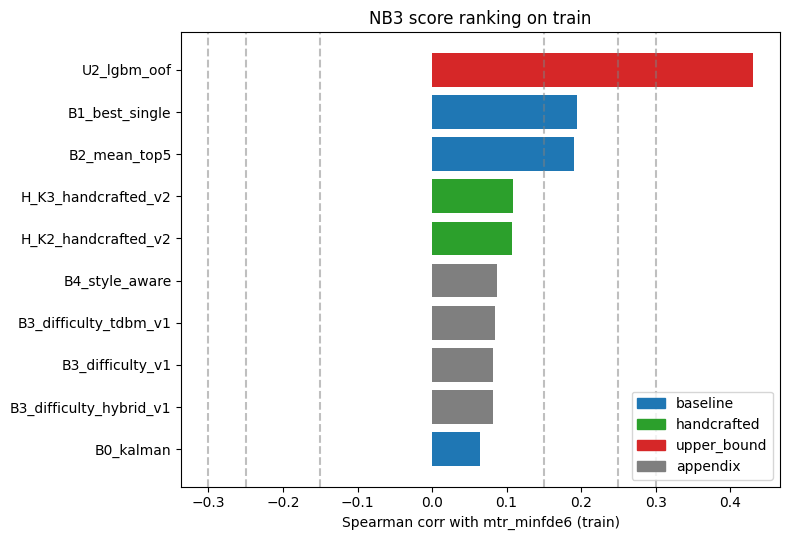

In [8]:
def _spearman(score: np.ndarray, err: pd.Series) -> tuple[float, int]:
    s = pd.Series(score)
    e = pd.to_numeric(err, errors='coerce').reset_index(drop=True)
    m = s.notna() & e.notna()
    if m.sum() < 50:
        return float('nan'), int(m.sum())
    return float(s[m].corr(e[m], method='spearman')), int(m.sum())


err_train = train[PRIMARY_ERROR].reset_index(drop=True)

rows = []
for name, arr in {**candidate_scores, **appendix_scores}.items():
    rho, n = _spearman(np.asarray(arr), err_train)
    rows.append({
        'score': name,
        'category': ('appendix' if name.startswith(('B3_', 'B4_')) else
                      'handcrafted' if name.startswith('H_') else
                      'upper_bound' if name.startswith('U') else 'baseline'),
        'spearman': rho,
        'valid_n': n,
    })

ranking = pd.DataFrame(rows)
ranking = ranking.reindex(ranking['spearman'].abs().sort_values(ascending=False).index).reset_index(drop=True)
ranking.to_csv(METRICS / 'nb3_score_ranking_train.csv', index=False)
print(ranking.to_string(index=False))

if not ranking.empty:
    fig, ax = plt.subplots(figsize=(8, 0.4 * len(ranking) + 1.5))
    order = ranking.iloc[::-1]
    colors = {'baseline': '#1f77b4', 'handcrafted': '#2ca02c',
              'upper_bound': '#d62728', 'appendix': '#7f7f7f'}
    bar_colors = [colors.get(c, '#888') for c in order['category']]
    ax.barh(order['score'], order['spearman'], color=bar_colors)
    for thr, label in [(0.15, '|rho|=0.15 NB2 gate'),
                        (0.25, '|rho|=0.25 composite GO'),
                        (0.30, '|rho|=0.30 U2 STOP floor')]:
        ax.axvline( thr, linestyle='--', alpha=0.5, color='gray')
        ax.axvline(-thr, linestyle='--', alpha=0.5, color='gray')
    ax.set_xlabel(f'Spearman corr with {PRIMARY_ERROR} (train)')
    ax.set_title('NB3 score ranking on train')
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
    ax.legend(handles, list(colors.keys()), loc='lower right')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'nb3_score_ranking.png', dpi=120, bbox_inches='tight')
    plt.show()

## 6. LightGBM feature importances (diagnostic, not used for decision)

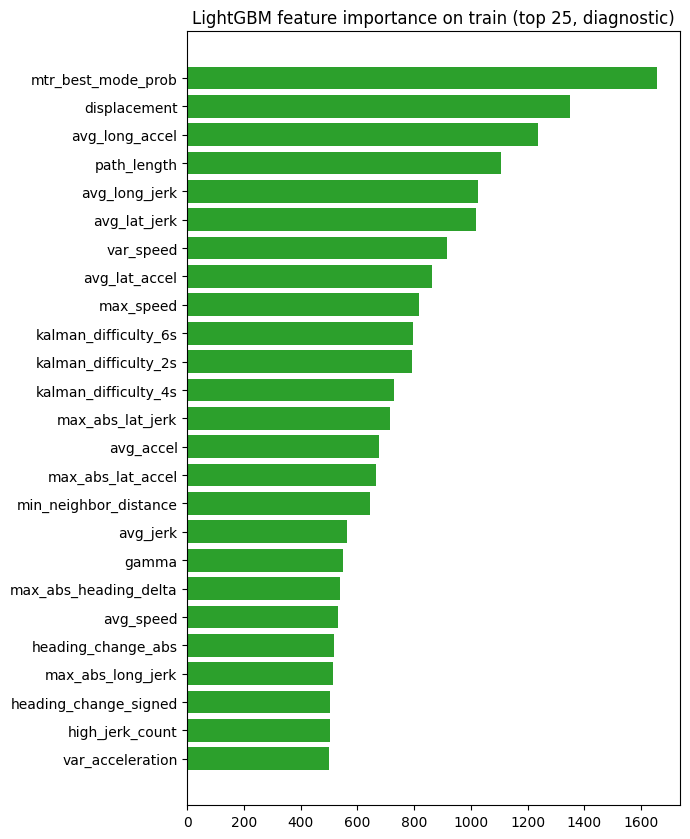

              feature  importance
   mtr_best_mode_prob        1655
         displacement        1350
       avg_long_accel        1238
          path_length        1105
        avg_long_jerk        1025
         avg_lat_jerk        1019
            var_speed         915
        avg_lat_accel         864
            max_speed         816
 kalman_difficulty_6s         797
 kalman_difficulty_2s         794
 kalman_difficulty_4s         730
     max_abs_lat_jerk         714
            avg_accel         676
    max_abs_lat_accel         665
min_neighbor_distance         646
             avg_jerk         563
                gamma         550
max_abs_heading_delta         540
            avg_speed         530
   heading_change_abs         516
    max_abs_long_jerk         514
heading_change_signed         504
      high_jerk_count         504
     var_acceleration         501


In [9]:
if HAVE_LGBM and len(Xv) >= 500:
    gbm_full = LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=63,
        min_child_samples=50, subsample=0.8, colsample_bytree=0.8,
        random_state=0, n_jobs=-1, verbose=-1,
    )
    gbm_full.fit(Xv, yv)
    feat_names = list(Xv.columns)
    fi = pd.DataFrame({'feature': feat_names, 'importance': gbm_full.feature_importances_})
    fi = fi.sort_values('importance', ascending=False).head(25)
    fi.to_csv(TABLES / 'nb3_gbm_importance.csv', index=False)
    fig, ax = plt.subplots(figsize=(7, 0.3 * len(fi) + 1.0))
    ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='#2ca02c')
    ax.set_title('LightGBM feature importance on train (top 25, diagnostic)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'nb3_gbm_importance.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(fi.to_string(index=False))
else:
    print('skipping importance: LightGBM unavailable or too few rows')

## 7. Verdict

In [10]:
def _abs_sp(name: str) -> float:
    row = ranking[ranking['score'] == name]
    if row.empty:
        return float('nan')
    return float(abs(row['spearman'].iloc[0]))


def _row(name: str) -> dict:
    row = ranking[ranking['score'] == name]
    return row.iloc[0].to_dict() if not row.empty else {}


baseline_names = [n for n in ['B0_kalman', 'B1_best_single', 'B2_mean_top5']
                  if n in ranking['score'].values]
baseline_best_sp = float(ranking[ranking['score'].isin(baseline_names)]['spearman'].abs().max()) \
    if baseline_names else float('nan')

hand_names = [n for n in ranking['score'] if n.startswith('H_')]
best_hand_name = max(hand_names, key=_abs_sp, default=None)
best_hand = _row(best_hand_name) if best_hand_name else None

u2_sp = _abs_sp('U2_lgbm_oof')

GO_RHO    = 0.25
STOP_U2   = 0.30

decision = 'PIVOT'
reasons = []

if not np.isnan(u2_sp) and u2_sp < STOP_U2:
    decision = 'STOP'
    reasons.append(f'U2 |rho|={u2_sp:.3f} < {STOP_U2:.2f}: even a learned model cannot rank error well from these features.')
elif best_hand is not None and not np.isnan(baseline_best_sp):
    sp = abs(best_hand.get('spearman', 0.0))
    if sp >= GO_RHO and sp > baseline_best_sp:
        decision = 'GO'
        reasons.append(f'{best_hand["score"]} |rho|={sp:.3f} >= {GO_RHO:.2f} and beats best baseline ({baseline_best_sp:.3f}).')
    else:
        reasons.append(f'{best_hand["score"]} |rho|={sp:.3f} did not clear GO bar (need >= {GO_RHO:.2f} and > best baseline {baseline_best_sp:.3f}).')
        if not np.isnan(u2_sp) and u2_sp > baseline_best_sp:
            reasons.append(f'But U2 |rho|={u2_sp:.3f} > best baseline {baseline_best_sp:.3f}, so signal exists - PIVOT to better features.')
else:
    reasons.append('no handcrafted composite or baselines available')

verdict = {
    'primary_error': PRIMARY_ERROR,
    'split': 'train',
    'metric': 'spearman',
    'baseline_best_abs_spearman': baseline_best_sp,
    'best_hand': best_hand,
    'u2_lgbm_oof_abs_spearman': u2_sp,
    'thresholds': {'GO_RHO': GO_RHO, 'STOP_U2': STOP_U2},
    'decision': decision,
    'reasons': reasons,
}

with open(ARTIFACTS / 'nb3_verdict.json', 'w') as f:
    json.dump(verdict, f, indent=2, default=float)
print(json.dumps(verdict, indent=2, default=float))

{
  "primary_error": "mtr_minfde6",
  "split": "train",
  "metric": "spearman",
  "baseline_best_abs_spearman": 0.19464215629122386,
  "best_hand": {
    "score": "H_K3_handcrafted_v2",
    "category": "handcrafted",
    "spearman": 0.10831070248668451,
    "valid_n": 43128
  },
  "u2_lgbm_oof_abs_spearman": 0.43022359924545367,
  "thresholds": {
    "GO_RHO": 0.25,
    "STOP_U2": 0.3
  },
  "decision": "PIVOT",
  "reasons": [
    "H_K3_handcrafted_v2 |rho|=0.108 did not clear GO bar (need >= 0.25 and > best baseline 0.195).",
    "But U2 |rho|=0.430 > best baseline 0.195, so signal exists - PIVOT to better features."
  ]
}
